#  Nykaa E-Commerce Sales Analysis

##  Introduction
Nykaa is one of India’s leading e-commerce platforms specializing in beauty, wellness, and fashion products. With a vast range of products and customer interactions, analyzing its dataset can provide valuable insights into customer behavior, product performance, and overall business trends.

This project focuses on analyzing Nykaa's sales dataset using data analysis and visualization techniques to uncover meaningful patterns and insights.



##  Problem Statement
The objective of this project is to analyze the Nykaa dataset to:

- Understand customer purchasing behavior
- Identify top-performing products and categories
- Analyze sales trends and patterns
- Evaluate the relationship between variables like price, ratings, and discounts
- Detect factors influencing customer satisfaction and productivity

By performing exploratory data analysis (EDA) and visualization, we aim to generate actionable insights that can help improve business decisions and customer experience.



##  Tools & Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn



##  Dataset Information
The dataset contains details such as:
- Product Name
- Category
- Price
- Ratings
- Discounts
- Sales/Orders



##  Project Workflow
1. Data Loading
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Data Visualization
5. Insights & Conclusion

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##  Data Loading

The dataset is loaded using Pandas to begin analysis and verify the data.

In [54]:
df = pd.read_csv(r"C:\Users\yuvar\Downloads\nykaa_dataset.csv")
df.head()

,product_id,product_name,brand,category,price,discount_price,discount_percent,rating,reviews_count,skin_type,year,sales_count,revenue,wishlist_count,delivery_days,stock_status
0,1,Maybelline Haircare Product,Maybelline,Haircare,1007,805.60,20,4.1,2230.0,NaN,2024,910,916370,521,2,In Stock
1,2,Minimalist Haircare Product,Minimalist,Haircare,497,397.60,20,3.3,1512.0,NaN,2024,3822,1899534,1265,5,Out of Stock
2,3,Biotique Makeup Product,Biotique,Makeup,700,490.00,30,3.7,1582.0,NaN,2025,3142,2199400,1747,2,Out of Stock
3,4,Himalaya Makeup Product,Himalaya,Makeup,1511,1133.25,25,4.3,1731.0,NaN,2024,516,779676,362,5,In Stock
4,5,Nykaa Skincare Product,Nykaa,Skincare,506,379.50,25,3.6,1078.0,Combination,2024,4476,2264856,2370,7,Out of Stock


##  Data Overview

Basic information, statistical summary, and missing values are checked to understand the dataset structure.

In [55]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_id        2500 non-null   int64  
 1   product_name      2500 non-null   object 
 2   brand             2500 non-null   object 
 3   category          2500 non-null   object 
 4   price             2500 non-null   int64  
 5   discount_price    2500 non-null   float64
 6   discount_percent  2500 non-null   int64  
 7   rating            2375 non-null   float64
 8   reviews_count     2375 non-null   float64
 9   skin_type         260 non-null    object 
 10  year              2500 non-null   int64  
 11  sales_count       2500 non-null   int64  
 12  revenue           2500 non-null   int64  
 13  wishlist_count    2500 non-null   int64  
 14  delivery_days     2500 non-null   int64  
 15  stock_status      2500 non-null   object 
dtypes: float64(3), int64(8), object(5)
memory 

##  Top Products Analysis

Top 10 products are identified based on total revenue and visualized using a bar chart.

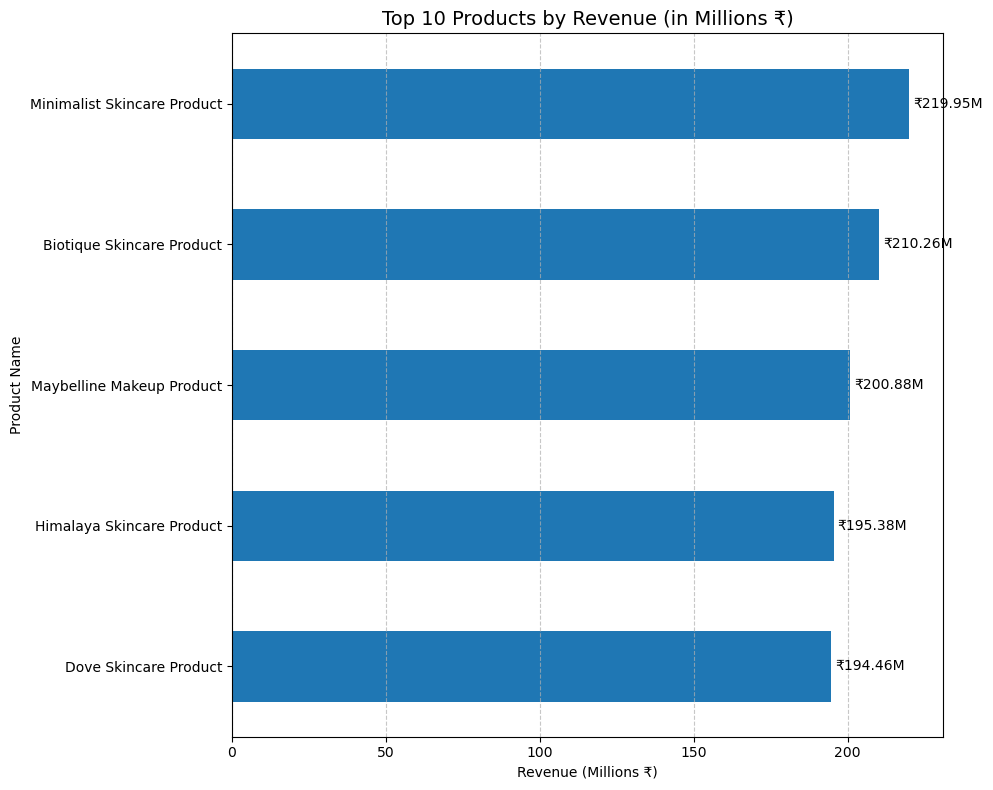

In [56]:
top_products = df.groupby('product_name')['revenue'].sum().nlargest() / 1_000_000  # convert to millions

plt.figure(figsize=(10,8))
ax = top_products.sort_values().plot(kind='barh')

# Add values on bars (in Millions)
for container in ax.containers:
    ax.bar_label(container, fmt='₹%.2fM', padding=3)

plt.title("Top 10 Products by Revenue (in Millions ₹)", fontsize=14)
plt.xlabel("Revenue (Millions ₹)")
plt.ylabel("Product Name")
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## 📊 Top Products Insights

- Minimalist Skincare Product is the highest revenue generator (~₹219.95M).
- Skincare products dominate the top 5, indicating high customer demand.
- Biotique and Maybelline also show strong performance across categories.
- Revenue among top products is closely distributed, showing strong competition.
- Well-known brands like Himalaya and Dove maintain consistent sales.
- Skincare category is the key driver of overall revenue.

##  Distribution of Product Revenue

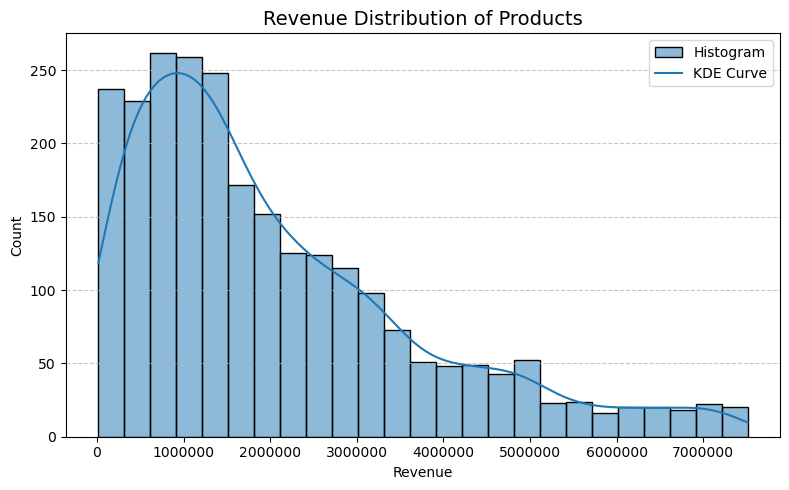

In [57]:
plt.figure(figsize=(8,5))

ax = sns.histplot(df['revenue'], kde=True)

# Add legend labels
ax.lines[0].set_label('KDE Curve')
ax.patches[0].set_label('Histogram')

plt.title("Revenue Distribution of Products", fontsize=14)
plt.xlabel("Revenue")
plt.ylabel("Count")

# Remove scientific notation
plt.ticklabel_format(style='plain', axis='x')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

##  Revenue Distribution Insights

- The revenue distribution is right-skewed (positively skewed), meaning most products have lower revenue while a few generate very high revenue.
- Majority of products fall in the lower revenue range (around 0 to 2M).
- A small number of products contribute to very high revenue (up to ~7M), indicating the presence of outliers.
- The long tail on the right shows that high-revenue products are rare but impactful.
- The distribution suggests that a few top-performing products drive a significant portion of total revenue.

##  Discount Price vs Revenue

Scatter plot is used to analyze the relationship between discount price and revenue.

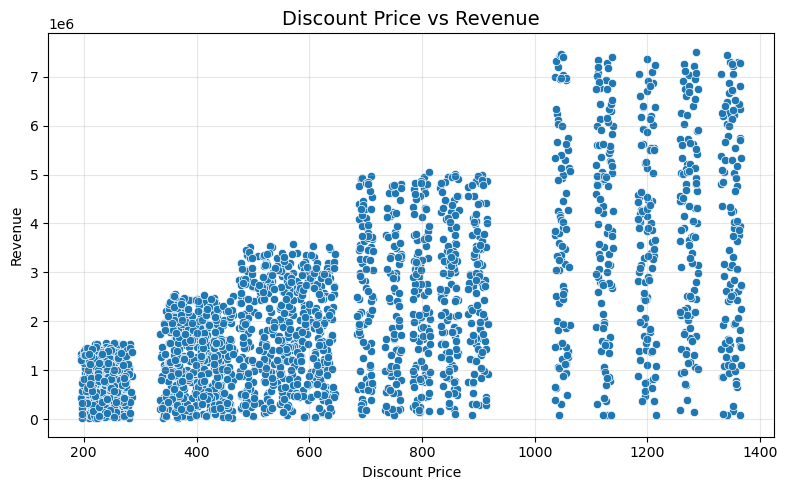

In [58]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='discount_price', y='revenue', data=df)

plt.title("Discount Price vs Revenue", fontsize=14)
plt.xlabel("Discount Price")
plt.ylabel("Revenue")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Insights

- There is a positive relationship between discount price and revenue.
- Higher discount prices tend to generate higher revenue.
- Some points are scattered, indicating variability in sales performance.
- Presence of outliers suggests certain products perform exceptionally well.
- Revenue is not solely dependent on discount price, other factors also influence it.

##  Products by Category

Countplot shows the number of products in each category.

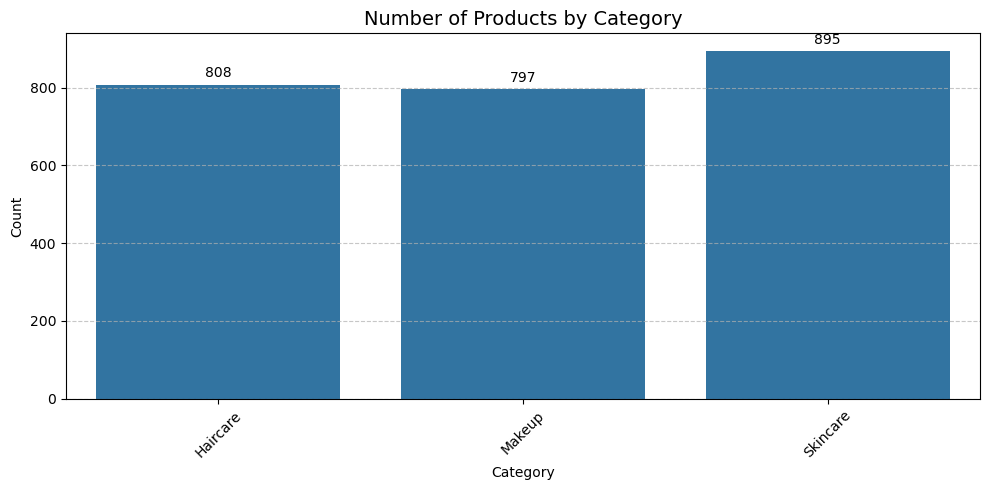

In [59]:
plt.figure(figsize=(10,5))

ax = sns.countplot(x='category', data=df)

plt.title("Number of Products by Category", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Count")

plt.xticks(rotation=45)

# Add values on bars
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

##  Insights

- Some categories have significantly more products than others.
- High-count categories indicate higher product availability and variety.
- Low-count categories may represent niche or less popular segments.
- Product distribution is uneven across categories.
- Categories with more products may contribute more to overall sales.

Count plot shows the number of orders in each category.”

##  Price Distribution (Box Plot)

Box plot is used to identify spread and outliers in price.

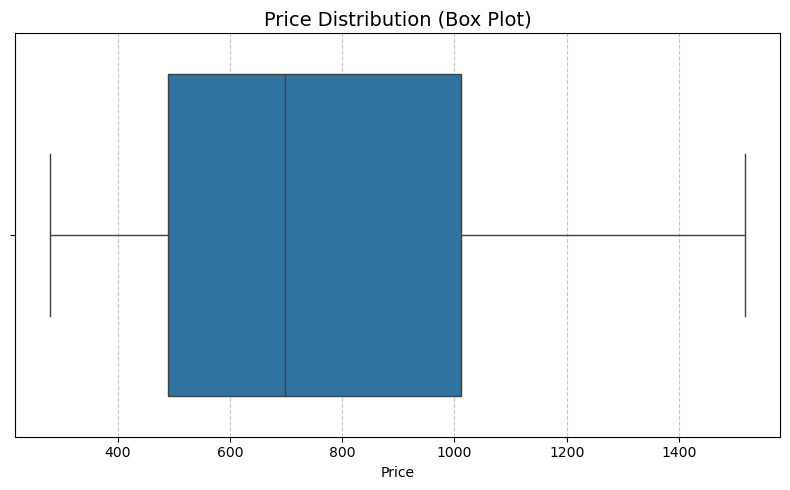

In [60]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['price'])

plt.title("Price Distribution (Box Plot)", fontsize=14)
plt.xlabel("Price")

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Insights

- The boxplot shows the distribution of product prices.
- Presence of outliers indicates some products are priced significantly higher than others.
- Most products fall within a lower to mid price range.
- The spread of the box shows variability in pricing.
- Skewness suggests price distribution is not uniform.

##  Correlation Analysis Heatmap

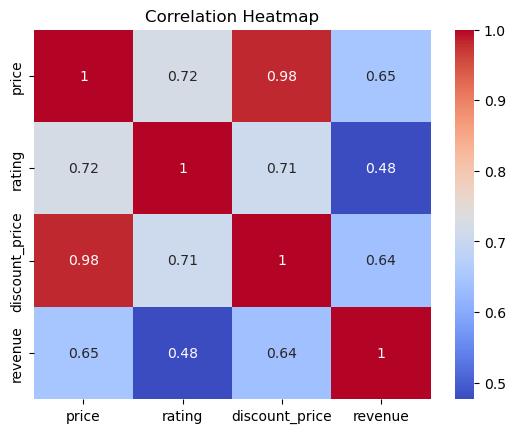

In [61]:
numeric_df = df[['price', 'rating', 'discount_price', 'revenue']]

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

##  Insights

- Price and discount price are highly correlated (~0.98).
- Revenue shows moderate correlation with price and discount price.
- Rating has the least impact on revenue.

“Heatmap is used to show correlation between numerical variables.”

some ml tech


##  Machine Learning - K-Means Clustering

K-Means clustering is an unsupervised machine learning algorithm used to group similar data points.

In this project:
- Features used: Revenue and Discount Price
- Number of clusters: 3
- Objective: Segment products based on similar patterns

This helps in identifying different product groups such as high-performing and low-performing products.

In [62]:
from sklearn.cluster import KMeans

X = df[['revenue', 'discount_price']]

kmeans = KMeans(n_clusters=3)
df['Cluster'] = kmeans.fit_predict(X)

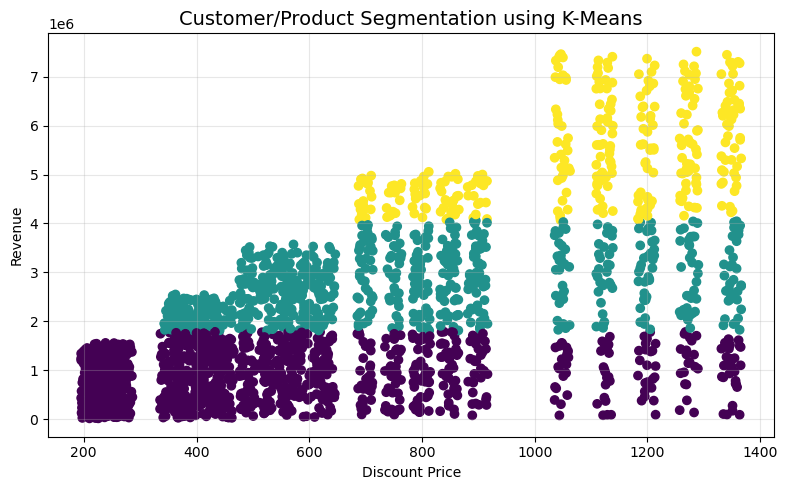

In [63]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Features
X = df[['revenue', 'discount_price']]

# Model
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# Plot clusters
plt.figure(figsize=(8,5))

plt.scatter(df['discount_price'], df['revenue'], c=df['Cluster'])

plt.title("Customer/Product Segmentation using K-Means", fontsize=14)
plt.xlabel("Discount Price")
plt.ylabel("Revenue")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

##  K-Means Clustering

K-Means clustering is used to segment products based on revenue and discount price.

- Products are grouped into 3 clusters.
- Each cluster represents similar pricing and revenue patterns.
- Helps in identifying high-value and low-value product groups.

##  ML Insights

- Products are divided into 3 clusters based on revenue and pricing.
- One cluster represents high revenue products.
- Another cluster shows low revenue products.
- Helps in understanding product segmentation.
- Useful for targeted marketing and pricing strategies.

##  Key Insights

- Skincare products generate the highest revenue.
- Minimalist is the top-performing product.
- Revenue distribution is right-skewed (few products earn very high revenue).
- Strong correlation between price and discount price.
- Revenue has moderate relationship with pricing.
- Ratings have less impact on revenue.
- Product distribution across categories is uneven.
- Higher discount price often leads to higher revenue.
- K-Means clustering groups products into different performance segments.

##  Conclusion

- A small number of products drive most of the revenue.
- Pricing strategy plays a key role in sales performance.
- Skincare category is the major revenue contributor.
- Product segmentation helps identify high and low-performing products.
- Businesses should focus on top products and optimize pricing strategies.